In [1]:
# imports
import numpy as np
import torch
from er_evaluation import pairwise_f, pairwise_precision, pairwise_recall
from torch.utils.data import DataLoader, ConcatDataset, random_split
from dataset_utils.Cresci17 import Cresci17, Cresci17SetTypes
from transformers import DistilBertTokenizer, AutoModel
import math
import re
import hdbscan
import matplotlib.pyplot as plt
import umap
from sklearn.metrics import confusion_matrix, adjusted_rand_score, normalized_mutual_info_score
from sklearn.preprocessing import StandardScaler
from hdbscan import approximate_predict
import joblib
from pipeline_utils import create_profile_vector, create_tweet_vector

/home/max/anaconda3/envs/social-media-bot-detection/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# load dataset
device = 'cuda' if torch.cuda.is_available() else 'cpu'

# use generator to get consistent dataset split between re-runs
generator = torch.Generator().manual_seed(42)
social_spam1_train, social_spam1_test = random_split(Cresci17(root="./datasets", subset_type=Cresci17SetTypes.SOCIAL_SPAM_1),[0.8,0.2], generator=generator)
fake_follower_train, fake_follower_test = random_split(Cresci17(root="./datasets", subset_type=Cresci17SetTypes.FAKE_FOLLOWER),[0.8,0.2], generator=generator)
genuine_user_train, genuine_user_test = random_split(Cresci17(root="./datasets", subset_type=Cresci17SetTypes.GENUINE_USER),[0.8,0.2], generator=generator)
traditional_spam = Cresci17(root="./datasets", subset_type=Cresci17SetTypes.TRADITIONAL_SPAM_1)

train_dataloader = DataLoader(ConcatDataset([social_spam1_train,genuine_user_train,fake_follower_train]), batch_size=None, batch_sampler=None, shuffle=True, num_workers=4, pin_memory=True)
test_dataloader = DataLoader(ConcatDataset([social_spam1_test,genuine_user_test,fake_follower_test, traditional_spam]), batch_size=None, batch_sampler=None, shuffle=True, num_workers=4, pin_memory=True)

/home/max/ProgrammingProjects/-Social-Media-Bot-Detection-with-Continuous-Learning/dataset_utils/Cresci17.py:80: DtypeWarning: Columns (0: favorite_count) have mixed types. Specify dtype option on import or set low_memory=False.
  self.tweet_data = pd.read_csv(tweet_data_path, encoding="latin-1", dtype={'id': str},


In [3]:
# initiate models
tokenizer = DistilBertTokenizer.from_pretrained("distilbert-base-uncased")
model = AutoModel.from_pretrained("distilbert-base-uncased").to(device)
dim_reducer = umap.UMAP(n_components=15, n_neighbors=20, min_dist=0.1, metric="cosine")
clusterer = hdbscan.HDBSCAN(min_cluster_size=5, prediction_data=True)

# training loop
ground_truth_labels = []
profile_vectors = []
tweet_vectors = []
for i, batch in enumerate(train_dataloader):
    data, label = batch
    # get feature vectors
    profile_embed = create_profile_vector(data)
    tweet_embeds = create_tweet_vector(data, tokenizer, model, max_tweets= 200, batch_size = 50)

    # pool tweet vectors
    tweet_vec = torch.mean(tweet_embeds, dim=0, dtype=torch.float32)

    # append feature vectors and ground truth
    profile_vectors.append(profile_embed)
    tweet_vectors.append(tweet_vec)
    ground_truth_labels.append(label)
    print(i)

# reduce tweet vectors in dimensionality
reduced_tweet_vectors = dim_reducer.fit_transform(tweet_vectors)
reduced_tweet_vectors = np.nan_to_num(reduced_tweet_vectors, nan=0.0, posinf=0.0, neginf=0.0)

# scale profile vectors
scaler = StandardScaler()
scaled_profile_vectors = scaler.fit_transform(profile_vectors)

# combine feature vectors
embedding_features = [np.concatenate((t1, t2), axis=0) for t1, t2 in zip(reduced_tweet_vectors, scaled_profile_vectors)]

# perform clustering
cluster_labels = clusterer.fit_predict(embedding_features)

Loading weights: 100%|██████████| 100/100 [00:00<00:00, 8991.97it/s]
DistilBertModel LOAD REPORT from: distilbert-base-uncased
Key                     | Status     |  | 
------------------------+------------+--+-
vocab_layer_norm.weight | UNEXPECTED |  | 
vocab_projector.bias    | UNEXPECTED |  | 
vocab_layer_norm.bias   | UNEXPECTED |  | 
vocab_transform.bias    | UNEXPECTED |  | 
vocab_transform.weight  | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


0
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
27
28
29
30
31
32
33
34
35
36
37
38
39
40
41
42
43
44
45
46
47
48
49
50
51
52
53
54
55
56
57
58
59
60
61
62
63
64
65
66
67
68
69
70
71
72
73
74
75
76
77
78
79
80
81
82
83
84
85
86
87
88
89
90
91
92
93
94
95
96
97
98
99
100
101
102
103
104
105
106
107
108
109
110
111
112
113
114
115
116
117
118
119
120
121
122
123
124
125
126
127
128
129
130
131
132
133
134
135
136
137
138
139
140
141
142
143
144
145
146
147
148
149
150
151
152
153
154
155
156
157
158
159
160
161
162
163
164
165
166
167
168
169
170
171
172
173
174
175
176
177
178
179
180
181
182
183
184
185
186
187
188
189
190
191
192
193
194
195
196
197
198
199
200
201
202
203
204
205
206
207
208
209
210
211
212
213
214
215
216
217
218
219
220
221
222
223
224
225
226
227
228
229
230
231
232
233
234
235
236
237
238
239
240
241
242
243
244
245
246
247
248
249
250
251
252
253
254
255
256
257
258
259
260
261
262
263
264
265
266
267
268
269
270
271
272
273
274
275
276
27

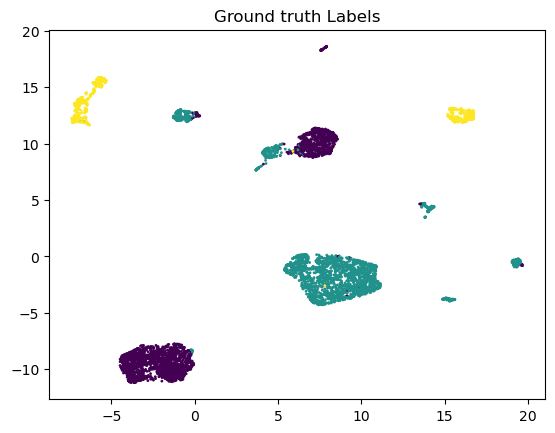

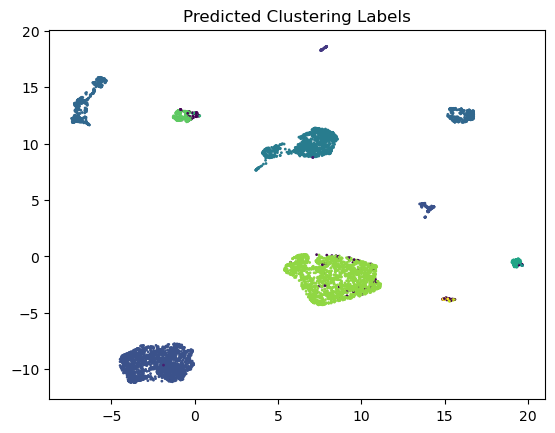

Predicted Labels:  [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10), np.int64(11), np.int64(-1)]
[[   0    0    0    0    0    0    0    0    0    0    0    0    0]
 [   0    0    0    0    0    0    0    0    0    0    0    0    0]
 [  44    7   60 1855    0  797    6    1    9    0    0    0    0]
 [  92    0    0  120    2  242    1  113    2  187 1877   23   22]
 [   4    0    0    0  784    5    0    0    0    0    0    0    0]
 [   0    0    0    0    0    0    0    0    0    0    0    0    0]
 [   0    0    0    0    0    0    0    0    0    0    0    0    0]
 [   0    0    0    0    0    0    0    0    0    0    0    0    0]
 [   0    0    0    0    0    0    0    0    0    0    0    0    0]
 [   0    0    0    0    0    0    0    0    0    0    0    0    0]
 [   0    0    0    0    0    0    0    0    0    0    0    0    0]
 [   0    0    0    0    0    0    0    0    0    0    0    

In [5]:
# evaluation

# remap feature vectors to 2D representation for plotting
plot_reducer = umap.UMAP(n_components=2, n_neighbors=15, min_dist=0.1)
coords = plot_reducer.fit_transform(embedding_features)
# plot ground truth
plt.title("Ground truth Labels")
plt.scatter(coords[:, 0], coords[:, 1], s=1, c=ground_truth_labels)
plt.show()
# plot predictions labels
plt.title("Predicted Clustering Labels")
plt.scatter(coords[:, 0], coords[:, 1], s=1, c=cluster_labels)
plt.show()

# calculate metrics
print("Predicted Labels: ", list(set(cluster_labels)))
print(confusion_matrix(ground_truth_labels, cluster_labels))
print("Precision: ", pairwise_precision(cluster_labels, ground_truth_labels))
print("Recall: ", pairwise_recall(cluster_labels, ground_truth_labels))
print("F1 score", pairwise_f(cluster_labels, ground_truth_labels))
print("Adjusted Rand Index: ", adjusted_rand_score(ground_truth_labels, cluster_labels))
print("Normalized Mutual Info: ", normalized_mutual_info_score(ground_truth_labels, cluster_labels))

In [6]:
# save model parameters
models_to_save = {
    "reducer": dim_reducer,
    "scaler": scaler,
    "clusterer": clusterer
}
joblib.dump(models_to_save, "bot_detection_models.joblib")

['bot_detection_models.joblib']

In [7]:
# load existing model parameters
loaded_models = joblib.load("bot_detection_models.joblib")
dim_reducer = loaded_models["reducer"]
scaler = loaded_models["scaler"]
clusterer = loaded_models["clusterer"]

In [8]:
# testing loop

ground_truth_labels = []
profile_vectors = []
tweet_vectors = []
for i, batch in enumerate(test_dataloader):
    data, label = batch
    # get feature vectors
    profile_embed = create_profile_vector(data)
    tweet_embeds = create_tweet_vector(data, tokenizer, model, max_tweets= 50, batch_size = 200)

    # pool tweet vectors
    tweet_vec = torch.mean(tweet_embeds, dim=0, dtype=torch.float32)#torch.max(tweet_embeds, dim=0).values

    # append feature vectors and ground truth
    profile_vectors.append(profile_embed)
    tweet_vectors.append(tweet_vec)
    ground_truth_labels.append(label)
    print(i)

# reduce tweet vectors in dimensionality
reduced_tweet_vectors = dim_reducer.transform(tweet_vectors)
reduced_tweet_vectors = np.nan_to_num(reduced_tweet_vectors, nan=0.0, posinf=0.0, neginf=0.0)

# scale profile vectors
scaled_profile_vectors = scaler.transform(profile_vectors)

# combine feature vectors
embedding_features = [np.concatenate((t1, t2), axis=0) for t1, t2 in zip(reduced_tweet_vectors, scaled_profile_vectors)]

# perform clustering
cluster_labels, _ = hdbscan.approximate_predict(clusterer= clusterer,points_to_predict= embedding_features)

0
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
27
28
29
30
31
32
33
34
35
36
37
38
39
40
41
42
43
44
45
46
47
48
49
50
51
52
53
54
55
56
57
58
59
60
61
62
63
64
65
66
67
68
69
70
71
72
73
74
75
76
77
78
79
80
81
82
83
84
85
86
87
88
89
90
91
92
93
94
95
96
97
98
99
100
101
102
103
104
105
106
107
108
109
110
111
112
113
114
115
116
117
118
119
120
121
122
123
124
125
126
127
128
129
130
131
132
133
134
135
136
137
138
139
140
141
142
143
144
145
146
147
148
149
150
151
152
153
154
155
156
157
158
159
160
161
162
163
164
165
166
167
168
169
170
171
172
173
174
175
176
177
178
179
180
181
182
183
184
185
186
187
188
189
190
191
192
193
194
195
196
197
198
199
200
201
202
203
204
205
206
207
208
209
210
211
212
213
214
215
216
217
218
219
220
221
222
223
224
225
226
227
228
229
230
231
232
233
234
235
236
237
238
239
240
241
242
243
244
245
246
247
248
249
250
251
252
253
254
255
256
257
258
259
260
261
262
263
264
265
266
267
268
269
270
271
272
273
274
275
276
27

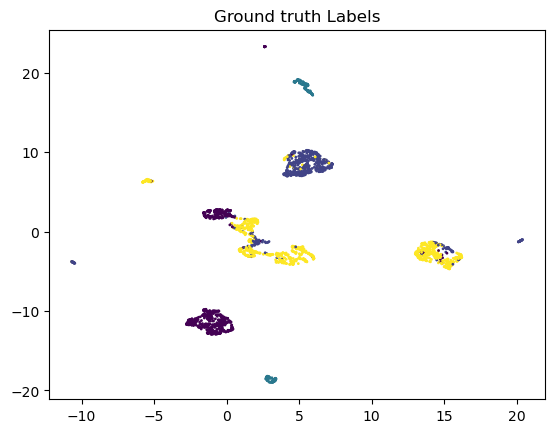

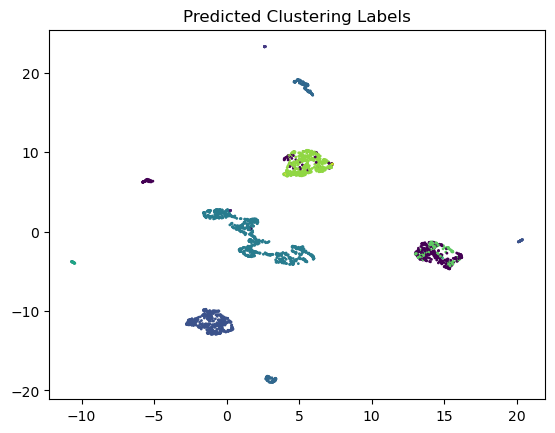

Predicted Labels:  [np.int32(0), np.int32(1), np.int32(2), np.int32(3), np.int32(4), np.int32(5), np.int32(6), np.int32(7), np.int32(8), np.int32(9), np.int32(10), np.int32(11), np.int32(-1)]
[[  0   0   0   0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0]
 [ 16   4  18 454   0 198   2   0   2   0   0   0   0]
 [ 34   0   0  29   0  73   0  25   0  37 466   5   1]
 [  0   0   0   0 198   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0]
 [333   0   0   0   0 578   0   0   0  88   1   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0]]
Precision:  0.7009417447567075
Recall:  0.48891661049483065
F1 score 0.5760384174943821
Adju

In [9]:
# evaluation

# remap feature vectors to 2D representation for plotting
plot_reducer = umap.UMAP(n_components=2, n_neighbors=15, min_dist=0.1)
coords = plot_reducer.fit_transform(embedding_features)
# plot ground truth
plt.title("Ground truth Labels")
plt.scatter(coords[:, 0], coords[:, 1], s=1, c=ground_truth_labels)
plt.show()
# plot predictions labels
plt.title("Predicted Clustering Labels")
plt.scatter(coords[:, 0], coords[:, 1], s=1, c=cluster_labels)
plt.show()

# calculate metrics
print("Predicted Labels: ", list(set(cluster_labels)))
print(confusion_matrix(ground_truth_labels, cluster_labels))
print("Precision: ", pairwise_precision(cluster_labels, ground_truth_labels))
print("Recall: ", pairwise_recall(cluster_labels, ground_truth_labels))
print("F1 score", pairwise_f(cluster_labels, ground_truth_labels))
print("Adjusted Rand Index: ", adjusted_rand_score(ground_truth_labels, cluster_labels))
print("Normalized Mutual Info: ", normalized_mutual_info_score(ground_truth_labels, cluster_labels))